# Origem dos parâmetros utilizados

## Rebnegger et al. (2016), *Pichia pastoris* em glicose
- **Parâmetros de Pirt**: $Y_{X/S,\max}=0.584\ \text{gX/gS},\ m_S=0.0031\ \text{gS/gX/h}$ vêm diretamente do artigo de **Rebnegger et al. (2016, *Applied and Environmental Microbiology*)**, estimados em retentostat e chemostato.  

- **Crescimento (Monod)**: $\mu_{\max}=0.18\ \text{h}^{-1},\ K_S=0.11\ \text{g/L}$ foram adotados como **valores plausíveis para leveduras em glicose**, conservadores em relação a máximos (~0.2–0.3 h⁻¹).  

- **Condições iniciais**: $X_0=0.05\ \text{g/L},\ S_0=3.0\ \text{g/L}$ simulam uma batelada com glicose abundante, típica de ensaios laboratoriais.
 

🔗 Artigo: [Rebnegger et al., 2016 — *Applied and Environmental Microbiology*](https://doi.org/10.1128/AEM.00638-16)

---

**Resumo**: cada conjunto de parâmetros combina **valores reportados nos artigos** com **ajustes plausíveis baseados na literatura**, garantindo perfis de crescimento e consumo biologicamente realistas.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display

# =========================
# Modelos
# =========================
def mu_haldane(S, mu_max, Ks, Ki):
    S = np.clip(np.asarray(S), 0, None)
    return mu_max * S / (Ks + S + (S**2)/Ki)

def mu_monod(S, mu_max, Ks):
    S = np.clip(np.asarray(S), 0, None)
    return mu_max * S / (Ks + S)

def qS_pirt(mu, Yxs, mS):
    return mu / Yxs + mS

def rhs_batch(t, y, mu_fun, mu_params, Yxs, mS):
    X, S = y
    S = max(S, 0.0)
    mu = mu_fun(S, **mu_params)
    dXdt = mu * X
    dSdt = -qS_pirt(mu, Yxs, mS) * X
    return [dXdt, dSdt]

# =========================

t_span = (0.0, 22.0)
t_eval = np.linspace(*t_span, 600)

reb_params_mu = dict(mu_max=0.18, Ks=0.11)  # h^-1, g/L
reb_Yxs = 0.584
reb_mS  = 0.0031
X0_reb, S0_reb = 0.05, 3.00  # g/L

sol_reb = solve_ivp(
    rhs_batch, t_span, [X0_reb, S0_reb],
    args=(lambda S, **p: mu_monod(S, **p), reb_params_mu, reb_Yxs, reb_mS),
    t_eval=t_eval, rtol=1e-7, atol=1e-9
)


In [2]:
def tabela_por_hora(sol, titulo, t_max=22):
    # tempos inteiros dentro do intervalo da simulação
    t_horas = np.arange(0, min(t_max, sol.t[-1]) + 1, 2.0)

    # interpolação sobre o grid t_eval já calculado
    X_interp = np.interp(t_horas, sol.t, sol.y[0])
    S_interp = np.interp(t_horas, sol.t, sol.y[1])

    df = pd.DataFrame({
        "tempo_h": t_horas,
        "substrato_S_gL": S_interp,
        "celulas_X_gL": X_interp,
    })
    df = df[["tempo_h", "substrato_S_gL", "celulas_X_gL"]].copy()
    df.columns.name = titulo
    return df

df_reb = tabela_por_hora(sol_reb, "Rebnegger 2016 — Monod + Pirt", t_max=22)

display(df_reb.head().style.format({"substrato_S_gL": "{:.4f}", "celulas_X_gL": "{:.4f}"}))


Rebnegger 2016 — Monod + Pirt,tempo_h,substrato_S_gL,celulas_X_gL
0,0.000000,3.0000,0.0500
1,2.000000,2.9641,0.0708
2,4.000000,2.9133,0.1001
3,6.000000,2.8415,0.1416
4,8.000000,2.7401,0.2002


In [3]:
# Parâmetros do ruído
mean = 0.0       # média do ruído
std_X = 0.05     # desvio padrão para X
std_S = 0.05     # desvio padrão para S

# Copiar o DataFrame para não sobrescrever o original
df_noisy = df_reb.copy()

# Adicionar ruído gaussiano às colunas de interesse
idx = df_reb.index[1:]

df_noisy.loc[idx, "celulas_X_gL"] = df_reb.loc[idx, "celulas_X_gL"] + np.random.normal(mean, std_X, size=len(idx))
df_noisy.loc[idx, "substrato_S_gL"] = df_reb.loc[idx, "substrato_S_gL"] + np.random.normal(mean, std_S, size=len(idx))

df_noisy = df_noisy.clip(lower=0)


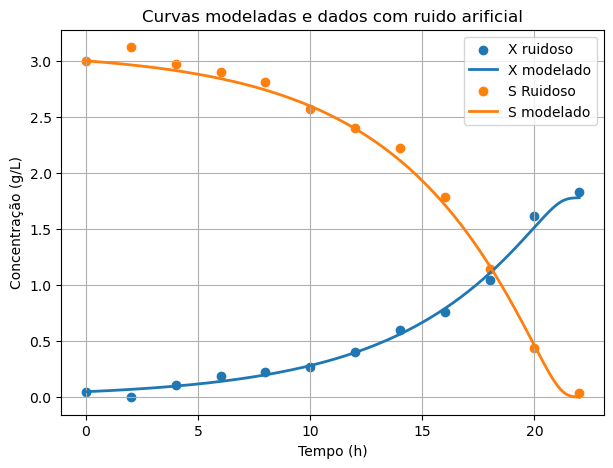

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(df_noisy["tempo_h"], df_noisy["celulas_X_gL"], label="X ruidoso")
plt.plot(sol_reb.t, sol_reb.y[0], lw=2, label="X modelado")

plt.scatter(df_noisy["tempo_h"], df_noisy["substrato_S_gL"], label="S Ruidoso")
plt.plot(sol_reb.t, sol_reb.y[1], lw=2, label="S modelado")

plt.xlabel("Tempo (h)")
plt.ylabel("Concentração (g/L)")
plt.title("Curvas modeladas e dados com ruido arificial")
plt.grid(True); plt.legend(); plt.show()


In [5]:
df_noisy.head()

Rebnegger 2016 — Monod + Pirt,tempo_h,substrato_S_gL,celulas_X_gL
0,0.0,3.000000,0.050000
1,2.0,3.121429,0.001534
2,4.0,2.971475,0.108785
3,6.0,2.904632,0.186982
4,8.0,2.813256,0.225855


In [6]:
df_noisy.to_json("dados.json", orient="records", indent=2)